# dmpbridge — Comparison Dashboard

Central view across both models and all experiment variants.  
For per-model deep dives see `eval_llama3.3-70b.ipynb` and `eval_llama3.1-8b.ipynb`.  
For the full decision record see `experiment_log.ipynb`.

| Section | Content |
|---|---|
| 1 | Executive summary — all key numbers at a glance |
| 2 | Model comparison — llama3.3:70b vs llama3.1:8b |
| 3 | Cross-model error analysis — shared vs unique errors |
| 4 | Error drill-down — interactive block filter |

## Setup

In [ ]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",     "grid.linewidth":0.5,
    "text.color":"#111111",     "axes.labelcolor":"#111111",
    "xtick.color":"#111111",    "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True, "legend.edgecolor":"#cccccc",
    "figure.dpi":120,
})

MODEL_COLORS = {"llama3.3:70b": "#2563eb", "llama3.1:8b": "#dc2626"}

TAGS = {
    "llama3.3:70b": "llama3.3-70b",
    "llama3.1:8b":  "llama3.1-8b",
}

def _snum(p):
    s = p.stem if hasattr(p, "stem") else p
    return int(s.replace("_dmp","").replace("sample",""))

samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)

def _f1(conf, lbl):
    tp = conf.get(lbl,{}).get(lbl,0)
    fp = sum(conf.get(o,{}).get(lbl,0) for o in LABELS if o!=lbl)
    fn = sum(v for p,v in conf.get(lbl,{}).items() if p!=lbl)
    p_ = tp/(tp+fp) if (tp+fp) else 0.
    r_ = tp/(tp+fn) if (tp+fn) else 0.
    return 2*p_*r_/(p_+r_) if (p_+r_) else 0.

def load_variant(tag):
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in samples:
        stem = mp.stem.replace("_dmp","")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists():
            continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl,preds in c.items():
            for pl,cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l,{}).get(l,0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample":stem,"total":n,"correct":tp,
                     "errors":n-tp,"accuracy":tp/n if n else 0})
    return pd.DataFrame(rows), conf

# Load all four variants
variants = {k: load_variant(v) for k,v in TAGS.items()}
print("Loaded variants:")
for model,(df,_) in variants.items():
    if df.empty: print(f"  MISSING  {model}"); continue
    tc,tn = int(df["correct"].sum()), int(df["total"].sum())
    print(f"  {model:<14}  {tc}/{tn}  ({tc/tn*100:.1f}%)")

## 1 — Executive Summary

In [2]:
KEY_LABELS = ["question.text", "section.description", "answer.text"]

print("=" * 72)
print("  dmpbridge — Comparison Dashboard")
print("=" * 72)
hdr = f"{'Variant':<28}  {'Accuracy':>8}  {'q.text F1':>10}  {'sec.desc F1':>12}  {'ans.text F1':>12}"
print("\n" + hdr)
print("-" * len(hdr))
for model,(df,conf) in variants.items():
    if df.empty: continue
    tc,tn = int(df["correct"].sum()), int(df["total"].sum())
    acc   = tc/tn*100
    f1_qt = _f1(conf,"question.text")*100
    f1_sd = _f1(conf,"section.description")*100
    f1_at = _f1(conf,"answer.text")*100
    print(f"{model:<28}  {acc:>7.1f}%  {f1_qt:>9.1f}%  {f1_sd:>11.1f}%  {f1_at:>11.1f}%")
print("=" * 72)


  dmpbridge — Comparison Dashboard

Variant                       Accuracy   q.text F1   sec.desc F1   ans.text F1
------------------------------------------------------------------------------
llama3.3:70b  with rules         96.8%       90.5%         94.2%         99.0%
llama3.3:70b  no rules           95.6%       77.3%         87.7%         99.0%
llama3.1:8b  with rules          69.0%       33.8%         40.0%         80.2%
llama3.1:8b  no rules            68.4%       27.4%         40.5%         80.2%


## 2 — Model Comparison


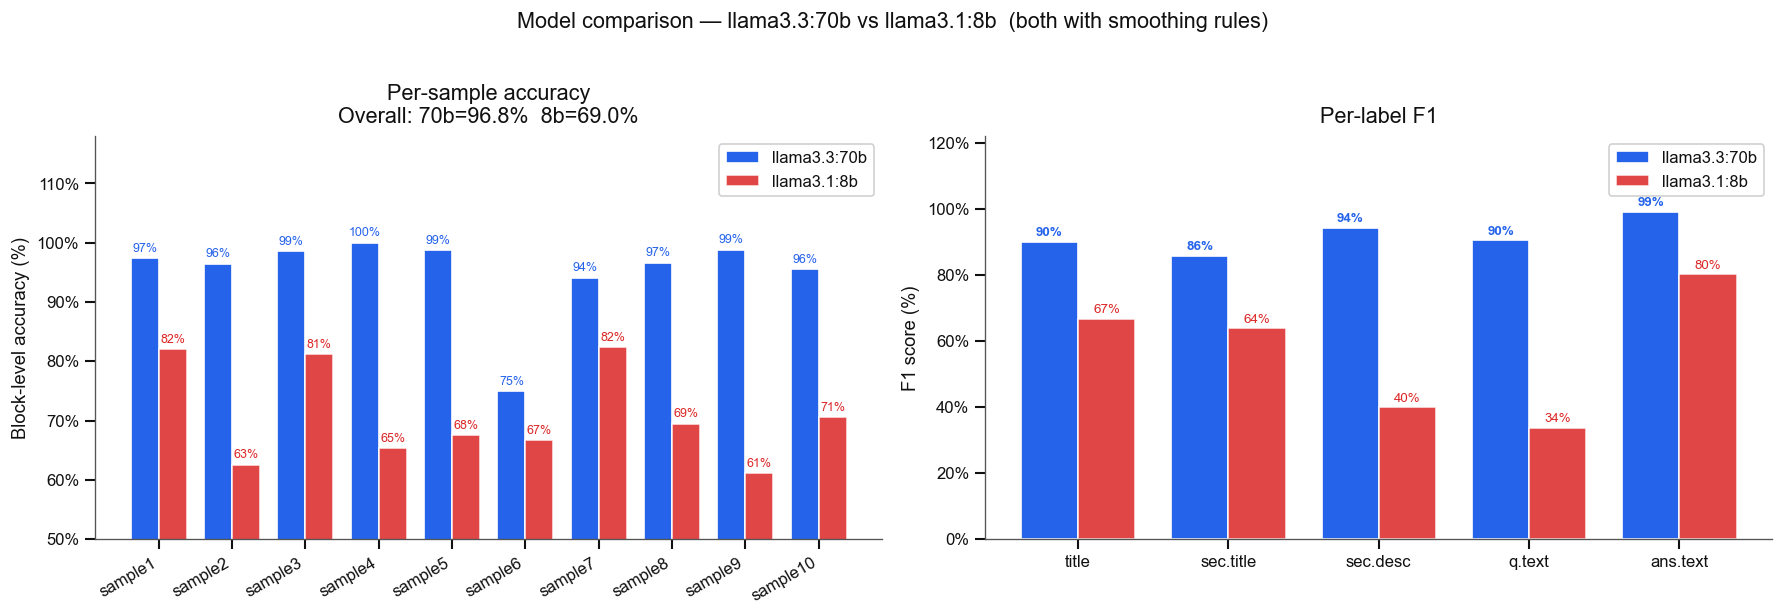

In [3]:
df70, conf70 = variants["llama3.3:70b"]
df8,  conf8  = variants["llama3.1:8b"]

x_labels = sorted(df70["sample"].tolist(), key=_snum)
df70s = df70.set_index("sample").loc[x_labels].reset_index()
df8s  = df8.set_index("sample").loc[x_labels].reset_index()

x, w = range(len(x_labels)), 0.38

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: per-sample accuracy ─────────────────────────────────────────────────
ax = axes[0]
bars70 = ax.bar([i-w/2 for i in x], df70s["accuracy"]*100,
                width=w, label="llama3.3:70b", color="#2563eb", edgecolor="white")
bars8  = ax.bar([i+w/2 for i in x], df8s["accuracy"]*100,
                width=w, label="llama3.1:8b",  color="#dc2626", edgecolor="white", alpha=0.85)
for bar in bars70:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=7.5, color="#2563eb")
for bar in bars8:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=7.5, color="#dc2626")
ov70 = df70["correct"].sum()/df70["total"].sum()
ov8  = df8["correct"].sum()/df8["total"].sum()
ax.set_xticks(list(x)); ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(50, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy\nOverall: 70b={ov70*100:.1f}%  8b={ov8*100:.1f}%", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9); sns.despine(ax=ax)

# ── Right: per-label F1 ───────────────────────────────────────────────────────
ax = axes[1]
f1_70 = [_f1(conf70,l)*100 for l in LABELS]
f1_8  = [_f1(conf8, l)*100 for l in LABELS]
x2 = range(len(LABELS))
b70 = ax.bar([i-w/2 for i in x2], f1_70, width=w,
             label="llama3.3:70b", color="#2563eb", edgecolor="white")
b8  = ax.bar([i+w/2 for i in x2], f1_8,  width=w,
             label="llama3.1:8b",  color="#dc2626", edgecolor="white", alpha=0.85)
for bar,v in zip(b70, f1_70):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{v:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#2563eb")
for bar,v in zip(b8, f1_8):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{v:.0f}%", ha="center", va="bottom", fontsize=8, color="#dc2626")
ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 122); ax.set_ylabel("F1 score (%)")
ax.set_title("Per-label F1", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9); sns.despine(ax=ax)

plt.suptitle("Model comparison — llama3.3:70b vs llama3.1:8b", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


In [4]:
print(f"{'Label':<22}  {'70b F1':>8}  {'8b F1':>8}  {'Diff':>8}")
print("-" * 54)
for lbl in LABELS:
    f70 = _f1(conf70, lbl)*100
    f8  = _f1(conf8,  lbl)*100
    d   = f8 - f70; s = "+" if d>=0 else ""
    print(f"{lbl:<22}  {f70:>7.1f}%  {f8:>7.1f}%  {s}{d:>6.1f}%")
print("-" * 54)
print(f"{'OVERALL accuracy':<22}  {ov70*100:>7.1f}%  {ov8*100:>7.1f}%  {(ov8-ov70)*100:>7.1f}%")


Label                     70b F1     8b F1      Diff
------------------------------------------------------
title                      90.0%     66.7%   -23.3%
section.title              85.7%     63.9%   -21.8%
section.description        94.2%     40.0%   -54.2%
question.text              90.5%     33.8%   -56.7%
answer.text                99.0%     80.2%   -18.8%
------------------------------------------------------
OVERALL accuracy           96.8%     69.0%    -27.8%


## 3 — Cross-Model Error Analysis

Compares errors block-by-block across both models.

| Category | Meaning |
|---|---|
| **shared** | Both models wrong — genuinely hard blocks |
| **70b only** | 70b wrong, 8b correct |
| **8b only** | 8b wrong, 70b correct — the bulk of 8b failures |
| **both correct** | Both right |

Shared errors are the highest-priority targets: no model choice or smoothing rule fixes them.

In [ ]:
# Compare errors block-by-block across both models
cross_rows = []

for mp in samples:
    stem  = mp.stem.replace("_dmp","")
    pp70  = LLM_DIR / f"{stem}_llama3.3-70b.json"
    pp8   = LLM_DIR / f"{stem}_llama3.1-8b.json"
    if not pp70.exists() or not pp8.exists():
        continue
    gold     = extract_gold(mp)
    blocks70 = json.loads(pp70.read_text(encoding="utf-8"))
    blocks8  = json.loads(pp8.read_text(encoding="utf-8"))

    for b70, b8 in zip(blocks70, blocks8):
        true_lbl  = match(b70["text"], gold)
        if true_lbl is None:
            continue          # skip unmatched blocks (no_match)
        pred70 = b70.get("label","answer.text")
        pred8  = b8.get("label","answer.text")
        err70  = (true_lbl != pred70)
        err8   = (true_lbl != pred8)

        if   err70 and err8:   cat = "shared"
        elif err70:            cat = "70b only"
        elif err8:             cat = "8b only"
        else:                  cat = "both correct"

        cross_rows.append({
            "sample":    stem,
            "text":      b70["text"][:120],
            "page":      b70.get("page","-"),
            "true":      true_lbl,
            "pred_70b":  pred70,
            "pred_8b":   pred8,
            "category":  cat,
        })

df_cross = pd.DataFrame(cross_rows)
counts   = df_cross["category"].value_counts()

total = len(df_cross)
print(f"Block-level error overlap  (total matched blocks: {total})\n")
for cat in ["both correct","shared","70b only","8b only"]:
    n   = counts.get(cat, 0)
    pct = n/total*100
    bar = "█" * int(pct/2)
    print(f"  {cat:<16} {n:>4}  ({pct:>5.1f}%)  {bar}")

shared_n = counts.get("shared",0)
only70_n = counts.get("70b only",0)
only8_n  = counts.get("8b only",0)
print(f"\nConclusion: {shared_n} blocks are hard for BOTH models.")
print(f"  {only70_n} blocks 70b-specific errors  (solvable with smoothing/fine-tuning)")
print(f"  {only8_n} blocks 8b-specific errors    (require model improvement)")

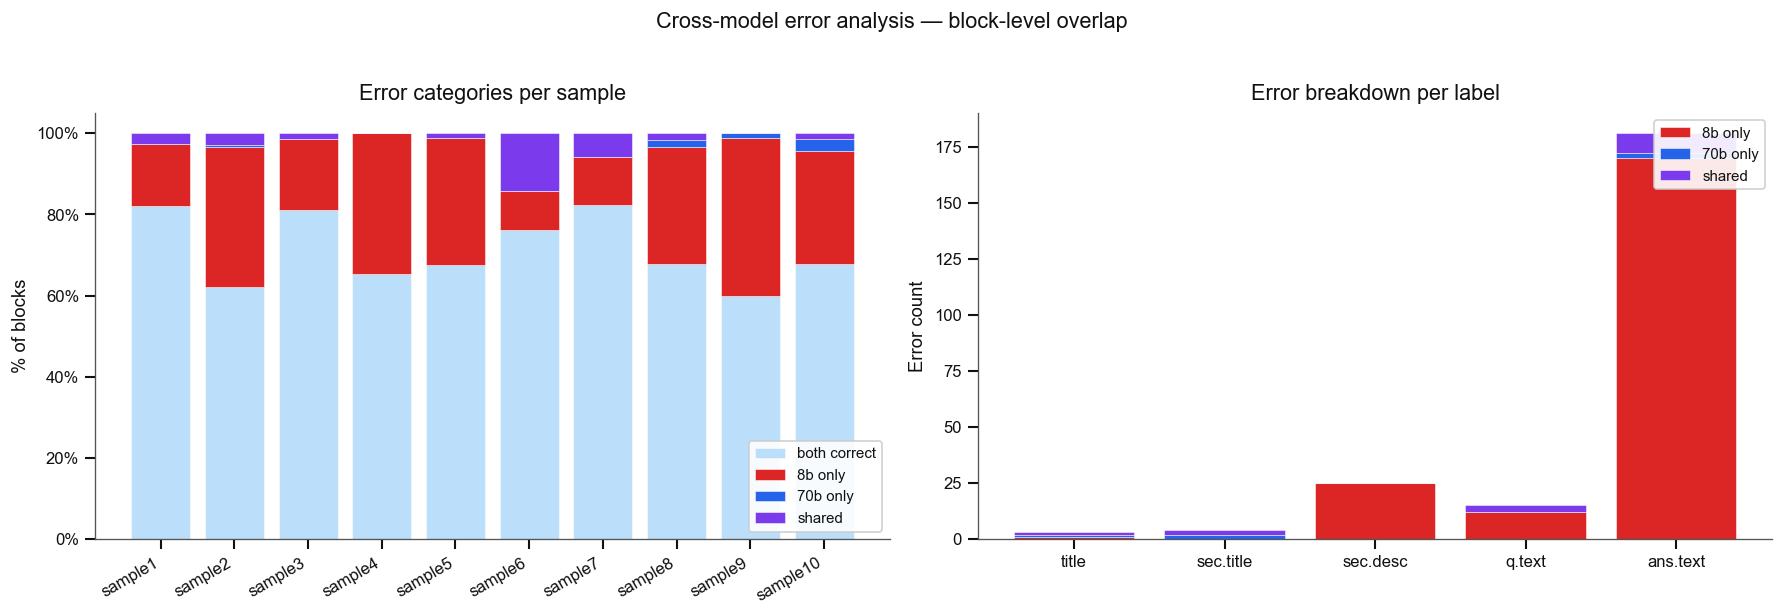

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: error category stacked bar per sample ───────────────────────────────
ax = axes[0]
CAT_COLORS = {
    "both correct": "#bbdefb",
    "8b only":      "#dc2626",
    "70b only":     "#2563eb",
    "shared":       "#7c3aed",
}
CATS = ["both correct","8b only","70b only","shared"]

x_labels = sorted(df_cross["sample"].unique().tolist(), key=_snum)
bottoms  = {s: 0 for s in x_labels}
for cat in CATS:
    vals = []
    for s in x_labels:
        sub  = df_cross[df_cross["sample"]==s]
        n    = (sub["category"]==cat).sum()
        tot  = len(sub)
        vals.append(n/tot*100 if tot else 0)
    ax.bar(x_labels, vals, bottom=[bottoms[s] for s in x_labels],
           label=cat, color=CAT_COLORS[cat], edgecolor="white", linewidth=0.3)
    for xi, (s, v) in enumerate(zip(x_labels, vals)):
        bottoms[s] += v

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 105); ax.set_ylabel("% of blocks")
ax.set_title("Error categories per sample", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

# ── Right: per-label breakdown of error types ─────────────────────────────────
ax = axes[1]
lbl_counts = {}
for lbl in LABELS:
    sub = df_cross[df_cross["true"]==lbl]
    lbl_counts[lbl] = {cat: (sub["category"]==cat).sum() for cat in CATS}

x2 = range(len(LABELS))
btm = [0]*len(LABELS)
for cat in ["8b only","70b only","shared"]:
    vals = [lbl_counts[l][cat] for l in LABELS]
    ax.bar(x2, vals, bottom=btm, label=cat, color=CAT_COLORS[cat],
           edgecolor="white", linewidth=0.3)
    btm = [b+v for b,v in zip(btm,vals)]
ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylabel("Error count")
ax.set_title("Error breakdown per label", pad=8)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

plt.suptitle("Cross-model error analysis — block-level overlap", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


In [9]:
# Shared errors — hardest blocks (both models wrong)
shared_df = df_cross[df_cross["category"]=="shared"].copy()
if shared_df.empty:
    print("No shared errors found.")
else:
    print(f"Shared errors ({len(shared_df)} blocks — both models wrong)\n")
    pd.set_option("display.max_colwidth", 90)
    display(shared_df[["sample","page","true","pred_70b","pred_8b","text"]]
            .sort_values(["true","sample"]).reset_index(drop=True))


Shared errors (15 blocks — both models wrong)



,sample,page,true,pred_70b,pred_8b,text
0,sample1,1,answer.text,question.text,question.text,The following data will be created as a result of this project:
1,sample10,2,answer.text,section.description,section.description,It is understood that the NSF Engineering Directorate requires data to be made availab...
2,sample2,3,answer.text,section.description,section.description,"principles of this Statement, data sharing should make digital research data available..."
3,sample2,4,answer.text,section.title,section.title,"Data Volume. Generally, the volume of data generated by CBES researchers should not pr..."
4,sample5,1,answer.text,question.text,question.text,"Raw data: Detailed information about how the data were obtained, including detailed co..."
5,sample6,1,answer.text,section.title,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,answer.text,section.title,section.title,3. Policies for access and sharing. Interested parties will be able to request data an...
7,sample6,1,answer.text,section.title,section.title,1
8,sample8,2,answer.text,section.description,question.text,"In keeping with standard ethical practices, it is expected that subsequent users of th..."
9,sample1,2,question.text,section.title,section.title,"Protections for privacy, rights, and confidentiality of human research participants:"


## 4 — Error Drill-Down

Edit `FILTER_MODEL`, `FILTER_TRUE`, `FILTER_PRED`, `FILTER_SAMPLE` to inspect any subset.

In [10]:
# ── Interactive filter — edit any of the four values below ───────────────────
FILTER_MODEL   = "llama3.1:8b"   # "llama3.3:70b" or "llama3.1:8b" or "both"
FILTER_TRUE    = "question.text"  # label or "" for all
FILTER_PRED    = ""               # label or "" for all
FILTER_SAMPLE  = ""               # e.g. "sample2" or "" for all

# ── Apply filter ──────────────────────────────────────────────────────────────
pred_col = "pred_70b" if FILTER_MODEL == "llama3.3:70b" else "pred_8b"
err_col  = "category"

mask = pd.Series([True]*len(df_cross), index=df_cross.index)

if FILTER_MODEL == "llama3.3:70b":
    mask &= df_cross["category"].isin(["70b only","shared"])
elif FILTER_MODEL == "llama3.1:8b":
    mask &= df_cross["category"].isin(["8b only","shared"])

if FILTER_TRUE:
    mask &= df_cross["true"] == FILTER_TRUE
if FILTER_PRED:
    mask &= df_cross[pred_col] == FILTER_PRED
if FILTER_SAMPLE:
    mask &= df_cross["sample"] == FILTER_SAMPLE

subset = df_cross[mask].reset_index(drop=True)
print(f"Filter: model={FILTER_MODEL}  true={FILTER_TRUE or 'any'}"
      f"  pred={FILTER_PRED or 'any'}  sample={FILTER_SAMPLE or 'all'}")
print(f"Matching blocks: {len(subset)}\n")
if not subset.empty:
    display(subset[["sample","page","true","pred_70b","pred_8b","text"]])


Filter: model=llama3.1:8b  true=question.text  pred=any  sample=all
Matching blocks: 15



,sample,page,true,pred_70b,pred_8b,text
0,sample1,1,question.text,question.text,section.title,"C. Metadata, other relevant data, and associated documentation:"
1,sample1,2,question.text,section.title,section.title,"Protections for privacy, rights, and confidentiality of human research participants:"
2,sample2,1,question.text,question.text,section.title,Content and Format. A statement of plans for data and metadata content and format incl...
3,sample2,2,question.text,section.title,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and pr...
4,sample2,2,question.text,section.description,section.description,"This should include, where appropriate:"
5,sample2,2,question.text,question.text,answer.text,a timeline for sharing and preservation that addresses both the minimum length of time...
6,sample2,2,question.text,question.text,answer.text,will be available and any anticipated delay to data access after research findings are...
7,sample2,2,question.text,question.text,answer.text,"any resources and capabilities (equipment, connections, systems, software, expertise, ..."
8,sample2,2,question.text,question.text,section.description,requested in the research proposal that are needed to meet the stated goals for sharin...
9,sample2,2,question.text,question.text,section.description,preservation. (This could reference the relevant section of the associated research pr...
